✅ Using GPU: /device:GPU:0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 1/60
1791/1791 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7652 - loss: 1.4586
Epoch 1: val_accuracy improved from -inf to 0.96913, saving model to /content/drive/MyDrive/SignApp/model.keras
1791/1791 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.7652 - loss: 1.4584 - val_accuracy: 0.9691 - val_loss: 0.7809
Epoch 2/60
1787/1791 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9455 - loss: 0.8970
Epoch 2: val_accuracy improved from 0.96913 to 0.97630, saving model to /content/drive/MyDrive/SignApp/model.keras
1791/1791 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9455 - loss: 0.8969 - val_accuracy: 0.9763 - val_loss: 0.7547
Epoch 3/60
1774/1791 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9572 - loss: 0.8527
Epoch 3: val_accuracy improved from 0.97630 to 0.97693, saving model to /content/drive/MyDrive/SignApp/model.keras

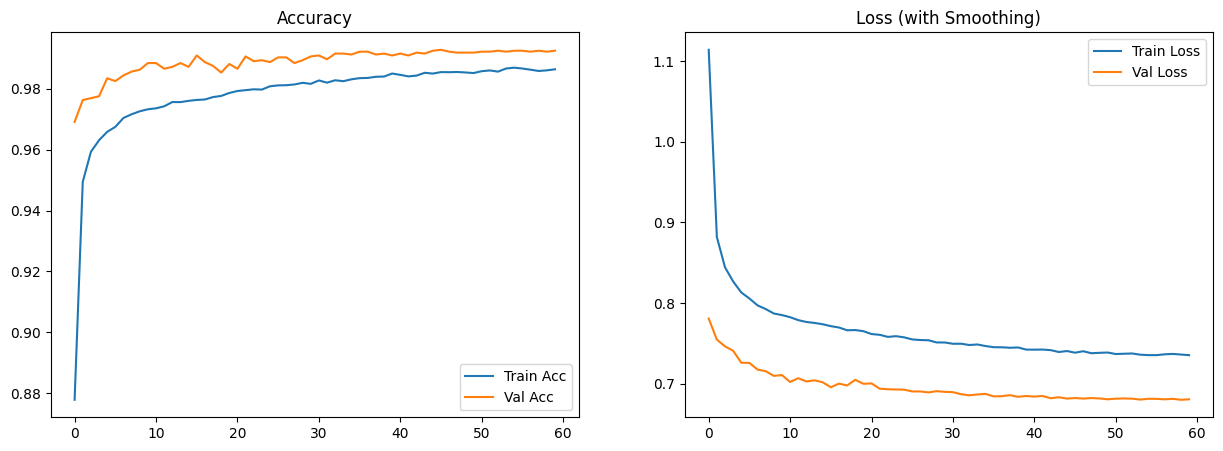


🏆 FINAL SOTA TEST ACCURACY: 98.74%


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical # Added for One-Hot
import pickle
from google.colab import drive

# --- 0. DEVICE CHECK ---
device_name = tf.test.gpu_device_name()
print(f"✅ Using GPU: {device_name}" if device_name else "⚠️ Using CPU")

drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/SignApp/'

# --- 1. LOAD & ONE-HOT ENCODE ---
df = pd.read_csv(base_path + 'landmarks_normalized.csv')
X = df.drop('label', axis=1).values
y_labels = df['label'].values

encoder = LabelEncoder()
y_integers = encoder.fit_transform(y_labels)
# CONVERT TO ONE-HOT FOR LABEL SMOOTHING
y_one_hot = to_categorical(y_integers)

with open(base_path + 'label_encoder.p', 'wb') as f:
    pickle.dump(encoder, f)

# --- 2. 3-WAY SPLIT ---
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_one_hot, test_size=0.05, stratify=y_one_hot, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.053, stratify=y_temp, random_state=42
)

# --- 3. SOTA SCHEDULER ---
EPOCHS = 60
BATCH_SIZE = 32
steps_per_epoch = len(X_train) // BATCH_SIZE

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=EPOCHS * steps_per_epoch,
    alpha=0.0001
)

# --- 4. MODEL ARCHITECTURE ---
model = Sequential([
    Input(shape=(63,)),
    Dense(256),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.2),
    Dense(len(encoder.classes_), activation='softmax')
])

# NOW WE CAN USE LABEL SMOOTHING
model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# --- 5. TRAINING ---
checkpoint = ModelCheckpoint(base_path + 'model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val, y_val), callbacks=[checkpoint, early_stop], verbose=1)

# --- 6. VISUALIZATION ---
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss (with Smoothing)')
plt.legend()
plt.show()

# --- 7. FINAL EVALUATION ---
model_best = tf.keras.models.load_model(base_path + 'model.keras')
test_loss, test_acc = model_best.evaluate(X_test, y_test, verbose=0)
print(f"\n🏆 FINAL SOTA TEST ACCURACY: {test_acc*100:.2f}%")

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step


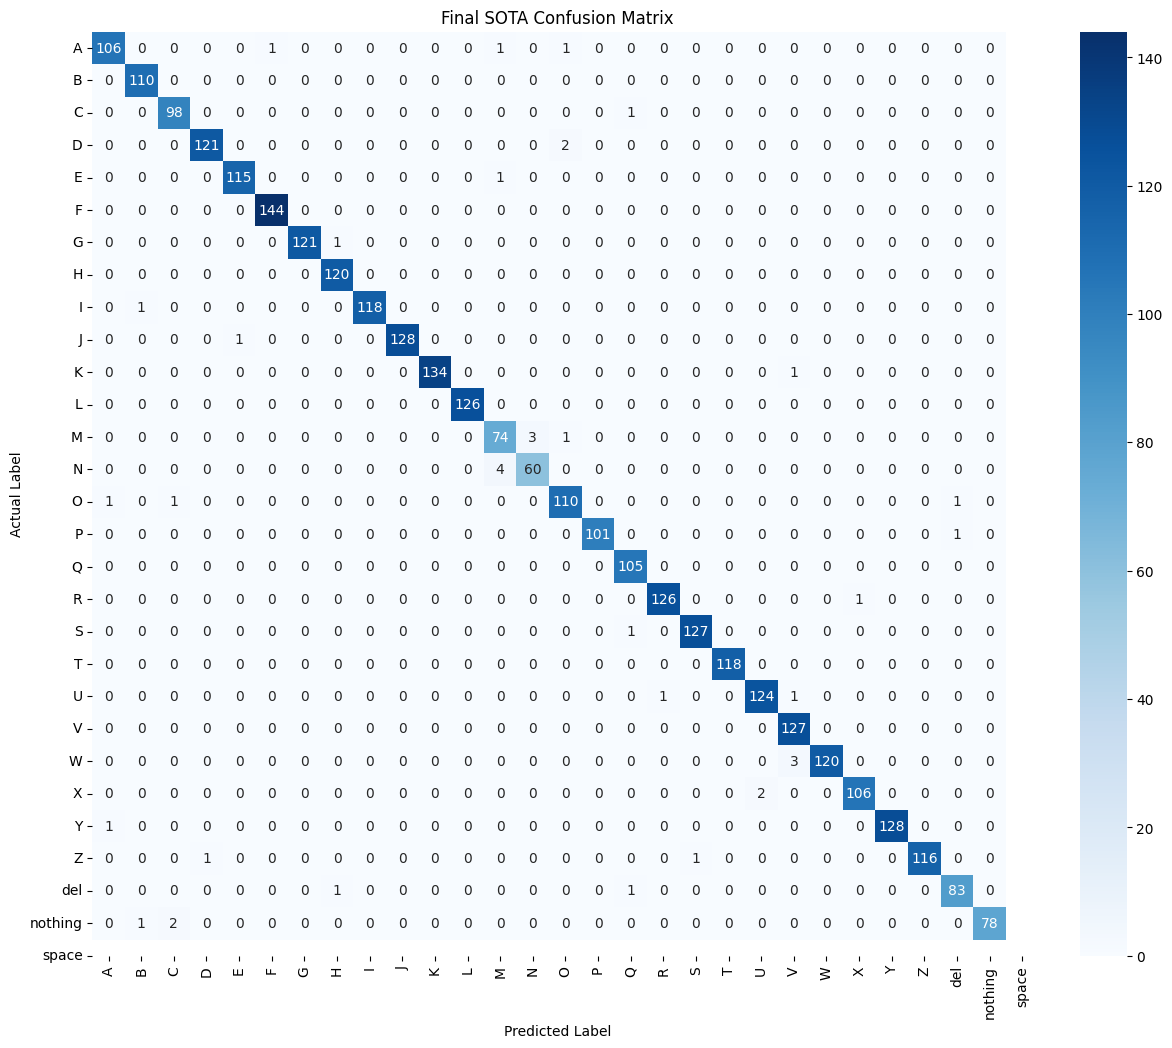

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Predict on the Test Set
y_pred_probs = model_best.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 2. Generate Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title('Final SOTA Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()